# DP10 - Anouck Jansen

| | |
|---|---|
| **Opdrachtgever** | Isala Ziekenhuis Zwolle |
| **Data Scientist** | Anouck Jansen |
| **Dataset** | Sepsis ICU dataset - Isala / Windesheim |
| **Opleverdatum** | 08-06-2026 |


**Leertaken:**
* **AD1**           - Evaluation
* **MC1**           - Data mining
* **AD3**           - Ethiek & Maatschappij

---

## **AN1 - Business understanding**

### Businessvraag

#### Hoofdvraag
> Kunnen we op basis van klinische meetwaarden (vitale parameters en laboratoriumwaarden) vroegtijdig voorspellen of een IC-patiënt sepsis zal ontwikkelen?

#### Sub-doel: Fairness
Als onderdeel van de evaluatie wordt onderzocht in hoeverre het model gelijk presteert voor verschillende patiëntgroepen (leeftijd en geslacht), en wat de ethische implicaties zijn van eventuele prestatieverschillen.

### Aanleiding:

Sepsis is een levensbedreigende aandoening waarbij het lichaam overmatig reageert op een infectie, wat kan leiden tot orgaanfalen en overlijden. Jaarlijks overlijden wereldwijd meer dan 11 miljoen mensen aan sepsis. In Nederland worden jaarlijks tienduizenden patiënten opgenomen met sepsis, waarvan een significant deel op de Intensive Care (IC). Vroegtijdige herkenning en behandeling is de sleutel tot overleving: elke vertraging van één uur in de behandeling verhoogt de sterfte significant.

Het Isala ziekenhuis in Zwolle heeft als één van de grotere perifere ziekenhuizen van Nederland een drukbezette IC-afdeling. Verpleegkundigen en artsen monitoren continu tientallen vitale parameters en laboratoriumwaarden per patiënt. Het handmatig herkennen van vroegtijdige sepsissignalen in al deze data is een uitdagende taak, zeker bij hoge werkdruk.

Een voorspellend model dat automatisch en continu de kans op sepsis berekent op basis van beschikbare meetwaarden, kan het klinische personeel ondersteunen om eerder in te grijpen. Dit kan levens redden en ziekenhuisopnames verkorten.

### Datavraag
> Kan een classificatiemodel, getraind op klinische features (vitale parameters en laboratoriumwaarden) per uur, voorspellen of een patiënt in de komende uren sepsis ontwikkelt (SepsisLabel = 1)?

### Organisatorische context

Dit onderzoek wordt uitgevoerd in het kader van de differentiatieopdracht Data Science voor Hogeschool Windesheim, in samenwerking met het Isala Ziekenhuis te Zwolle. Het Isala is een topklinisch opleidingsziekenhuis met een grote IC-afdeling. Het model is bedoeld als decision support tool voor IC-verpleegkundigen en -artsen: het signaleert risicovolle patiënten, waarna de behandelaar zelf de beslissing neemt.

### Maatschappelijke context

* **Patiëntveiligheid:** Sepsis heeft een hoge mortaliteit. Een eerder en betrouwbaarder signaleringsmodel kan directe levensreddende impact hebben voor IC-patiënten.
* **Werkdruk zorgpersoneel:** IC-personeel opereert onder hoge werkdruk. Een AI-ondersteund vroegwaarschuwingssysteem kan prioritering in zorgverlening ondersteunen zonder het klinisch oordeel te vervangen.
* **Fairness:** Het model wordt getraind op data van patiënten met wisselende leeftijden en geslachten. Als het model systematisch slechter presteert voor bepaalde groepen (bijvoorbeeld oudere patiënten of vrouwen), kan dit leiden tot ongelijke zorg. Dit wordt expliciet geanalyseerd als sub-doel van dit onderzoek.
* **Privacy:** De gebruikte dataset bevat geanonimiseerde medische gegevens. In een echte ziekenhuisomgeving zijn medische gegevens bijzondere persoonsgegevens (AVG Artikel 9) en vereist verwerking een expliciete juridische grondslag.
* **Automation bias:** Er bestaat een risico dat zorgverleners te veel vertrouwen op de modeluitkomst en hun eigen klinisch oordeel minder inzetten. Het model dient uitdrukkelijk als ondersteuning, niet als vervanging.
* **Klasse-onbalans:** Slechts ~1,8% van de observaties in de dataset heeft een sepsislabel. Een model dat altijd 0 voorspelt behaalt al 98,2% accuracy, wat misleidend is. Dit vraagt om specifieke evaluatiemetrics.

### Juridische implicaties

* **AVG Artikel 9 – Bijzondere persoonsgegevens:** Medische gegevens zijn bijzondere persoonsgegevens. Verwerking is in principe verboden, tenzij aan strikte voorwaarden is voldaan (o.a. expliciete toestemming of wetenschappelijk onderzoek met adequate waarborgen). De gebruikte dataset is voor dit onderzoek geanonimiseerd en valt daarmee buiten de directe werking van de AVG.
* **AI Act – Hoog risico:** Medische AI-systemen die worden ingezet voor diagnose of behandelbeslissingen vallen onder de hoog-risicocategorie van de EU AI Act (Annex III). Dit betekent dat bij daadwerkelijke inzet in het ziekenhuis eisen gelden op het gebied van transparantie, robuustheid, menselijk toezicht en documentatie.
* **MDR (Medical Device Regulation):** Software die wordt gebruikt voor klinische besluitvorming kan kwalificeren als medisch hulpmiddel en valt dan onder de EU MDR-regelgeving, inclusief CE-markering.

### Stakeholders

* **Isala Ziekenhuis Zwolle** – Opdrachtgever
* **IC-verpleegkundigen en intensivisten** – Eindgebruikers van het model
* **IC-patiënten** – Degenen wiens zorg direct beïnvloed wordt
* **Hogeschool Windesheim** – Onderwijsinstelling en begeleidende partij
* **Ethische commissie ziekenhuis** – Toetst inzet van AI in klinische praktijk

### KSF & KPI's

**KSF**  
Ontwikkeling van een model dat vroegtijdig en betrouwbaar sepsis kan signaleren bij IC-patiënten op basis van klinische meetwaarden.

**KPI's**
* Een **AUROC ≥ 0.80** behalen op de testset
* Een **recall (sensitivity) ≥ 0.70** voor de klasse `SepsisLabel = 1` (sepsis detecteren is kritisch)
* **Precision ≥ 0.30** voor de klasse `SepsisLabel = 1` (te veel fout-positieven belasten het personeel)
* Het verschil in AUROC tussen geslachten en leeftijdsgroepen kleiner dan **0.05** (fairness sub-doel)

### Databron

De gebruikte dataset is afkomstig van de Isala opdracht aangeboden via Hogeschool Windesheim. De dataset bevat per patiënt per uur gemeten klinische parameters gedurende het IC-verblijf. De trainset bevat **1.399.302 observaties** van **36.336 unieke patiënten**. De testset bevat **152.908 observaties** van **4.000 unieke patiënten** (zonder sepsislabel).

Beschikbare features:
* **Vitale parameters:** HR, O2Sat, Temp, SBP, MAP, DBP, Resp, EtCO2
* **Laboratoriumwaarden:** BaseExcess, HCO3, FiO2, pH, PaCO2, SaO2, AST, BUN, Alkalinephos, Calcium, Chloride, Creatinine, Bilirubin_direct, Glucose, Lactate, Magnesium, Phosphate, Potassium, Bilirubin_total, TroponinI, Hct, Hgb, PTT, WBC, Fibrinogen, Platelets
* **Patiëntkenmerken:** Age, Gender, Unit1, Unit2, HospAdmTime, ICULOS
* **Target:** SepsisLabel (0 = geen sepsis, 1 = sepsis)

#### Vital signs
| Kolomnaam | Beschrijving | Eenheid |
|---|---|---|
| HR | Hartslag (Heart Rate) | beats per minute |
| O2Sat | Pulse oximetry | % |
| Temp | Temperature | °C |
| SBP | Systolic BP | mm Hg |
| MAP | Mean arterial pressure | mm Hg |
| DBP | Diastolic BP | mm Hg |
| Resp | Respiration rate | breaths per minute |
| EtCO2 | End tidal carbon dioxide | mm Hg |

#### Laboratory values
| Kolomnaam | Beschrijving | Eenheid |
|---|---|---|
| BaseExcess | Excess bicarbonate | mmol/L |
| HCO3 | Bicarbonate | mmol/L |
| FiO2 | Fraction of inspired oxygen | 0–1 |
| pH | Zuurgraad van het bloed | — |
| PaCO2 | Partial pressure of carbon dioxide from arterial blood | mm Hg |
| SaO2 | Oxygen saturation from arterial blood | % |
| AST | Aspartate transaminas | IU/L |
| BUN | Blood urea nitrogen | mg/dL |
| Alkalinephos | Alkaline phosphatase | IU/L |
| Calcium | Calcium | mg/dL |
| Chloride | Chloride | mmol/L |
| Creatinine | Creatinine | mg/dL |
| Bilirubin_direct | Direct bilirubin | mg/dL |
| Bilirubin_total | Total bilirubin | mg/dL |
| Glucose | Serum glucos | mg/dL |
| Lactate | Lactic acid | mmol/L |
| Magnesium | Magnesium | mmol/L |
| Phosphate | Phosphate | mg/dL |
| Potassium | Potassiam | mmol/L |
| TroponinI | Troponin  | ng/mL |
| Hct | Hematocrit  | % |
| Hgb | Hemoglobin  | g/dL |
| PTT | Partial thromboplastin time  | seconds |
| WBC | Leukocyte coun | count/L |
| Fibrinogen | Fibrinogen concentration | mg/dL |
| Platelets | Platelet count | count/mL |

#### Patiënt- en opnamegegevens
| Kolomnaam | Beschrijving | Type |
|---|---|---|
| Age | Age | years |
| Gender | Geslacht | Binair Binair (0;female/1;male)|
| Unit1 | Administrative identifier for ICU unit (MICU) | Binair (0;false/1;true) |
| Unit2 | Administrative identifier for ICU unit (SICU) | Binair (0;false/1;true) |
| HospAdmTime | Time between hospital and ICU admission | Hours since ICU admission |
| ICULOS | ICU length of stay | hours since ICU admission |
| Hour | Uur van de observatie | Numeriek |

#### Target variabele
| Kolomnaam | Beschrijving |
|---|---|
| SepsisLabel | 0 = geen sepsis, 1 = sepsis aanwezig op dit meetmoment |

---

## **AN2 - Data Understanding**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from pathlib import Path

In [3]:
df_train = pd.read_csv('train_data.csv')
df_test  = pd.read_csv('test_data.csv')

print(f'Trainset: {df_train.shape[0]:,} rijen, {df_train.shape[1]} kolommen')
print(f'Testset:  {df_test.shape[0]:,} rijen, {df_test.shape[1]} kolommen')
df_train.head(10)

Trainset: 1,399,302 rijen, 44 kolommen
Testset:  152,908 rijen, 43 kolommen


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072
5,5,5,62.0,100.0,NaN,124.0,85.0,61.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,6,0,17072
6,6,6,61.0,100.0,NaN,101.0,75.0,58.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,7,0,17072
7,7,7,68.0,100.0,35.78,142.0,93.5,78.0,16.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,8,0,17072
8,8,8,71.0,100.0,NaN,121.0,74.0,91.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,9,0,17072
9,9,9,69.0,100.0,NaN,120.0,79.0,98.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,10,0,17072


In [4]:
df_train.describe()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
count,1.399302e+06,1.399302e+06,1.261070e+06,1.216615e+06,474304.000000,1.195492e+06,1.225052e+06,961600.000000,1.184880e+06,52020.000000,...,9319.000000,83243.000000,1.399302e+06,1.399302e+06,848885.000000,848885.000000,1.399294e+06,1.399302e+06,1.399302e+06,1.399302e+06
mean,2.551103e+01,2.551103e+01,8.459206e+01,9.719306e+01,36.977555,1.237281e+02,8.239274e+01,63.795128,1.873619e+01,32.925865,...,287.729520,195.940093,6.199812e+01,5.604073e-01,0.496395,0.503605,-5.614702e+01,2.700756e+01,1.821051e-02,5.917730e+04
std,2.884830e+01,2.884830e+01,1.734384e+01,2.945582e+00,0.773453,2.320404e+01,1.634168e+01,13.945080,5.098782e+00,7.931398,...,153.426372,104.158390,1.639975e+01,4.963377e-01,0.499987,0.499987,1.656790e+02,2.894534e+01,1.337120e-01,5.022381e+04
min,0.000000e+00,0.000000e+00,2.000000e+01,2.000000e+01,20.900000,2.000000e+01,2.000000e+01,20.000000,1.000000e+00,10.000000,...,34.000000,1.000000,1.400000e+01,0.000000e+00,0.000000,0.000000,-5.366860e+03,1.000000e+00,0.000000e+00,1.000000e+00
25%,9.000000e+00,9.000000e+00,7.200000e+01,9.600000e+01,36.500000,1.070000e+02,7.100000e+01,54.000000,1.500000e+01,28.000000,...,184.000000,126.000000,5.172000e+01,0.000000e+00,0.000000,0.000000,-4.675000e+01,1.100000e+01,0.000000e+00,9.996000e+03
50%,1.900000e+01,1.900000e+01,8.350000e+01,9.800000e+01,37.000000,1.210000e+02,8.000000e+01,62.000000,1.800000e+01,33.000000,...,251.000000,180.000000,6.400000e+01,1.000000e+00,0.000000,1.000000,-6.030000e+00,2.100000e+01,0.000000e+00,1.996200e+04
75%,3.300000e+01,3.300000e+01,9.600000e+01,9.950000e+01,37.500000,1.380000e+02,9.200000e+01,72.000000,2.150000e+01,38.000000,...,349.000000,244.000000,7.400000e+01,1.000000e+00,1.000000,1.000000,-4.000000e-02,3.400000e+01,0.000000e+00,1.098270e+05
max,3.350000e+02,3.350000e+02,2.800000e+02,1.000000e+02,50.000000,3.000000e+02,3.000000e+02,300.000000,1.000000e+02,100.000000,...,1760.000000,2322.000000,1.000000e+02,1.000000e+00,1.000000,1.000000,2.399000e+01,3.360000e+02,1.000000e+00,1.200000e+05


In de eerste tien rijen is al te zien dat de dataset veel missende waarden bevat, vooral bij laboratoriumwaarden. Dit is klinisch logisch: labtests worden niet elk uur afgenomen.

In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1399302 entries, 0 to 1399301
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1399302 non-null  int64  
 1   Hour              1399302 non-null  int64  
 2   HR                1261070 non-null  float64
 3   O2Sat             1216615 non-null  float64
 4   Temp              474304 non-null   float64
 5   SBP               1195492 non-null  float64
 6   MAP               1225052 non-null  float64
 7   DBP               961600 non-null   float64
 8   Resp              1184880 non-null  float64
 9   EtCO2             52020 non-null    float64
 10  BaseExcess        76344 non-null    float64
 11  HCO3              58809 non-null    float64
 12  FiO2              117251 non-null   float64
 13  pH                97571 non-null    float64
 14  PaCO2             78284 non-null    float64
 15  SaO2              48409 non-null    float64
 16  AST        

In [6]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 152908 entries, 0 to 152907
Data columns (total 43 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152908 non-null  int64  
 1   Hour              152908 non-null  int64  
 2   HR                137741 non-null  float64
 3   O2Sat             132859 non-null  float64
 4   Temp              50922 non-null   float64
 5   SBP               130453 non-null  float64
 6   MAP               133888 non-null  float64
 7   DBP               104056 non-null  float64
 8   Resp              128995 non-null  float64
 9   EtCO2             5616 non-null    float64
 10  BaseExcess        7801 non-null    float64
 11  HCO3              6219 non-null    float64
 12  FiO2              12114 non-null   float64
 13  pH                10002 non-null   float64
 14  PaCO2             8017 non-null    float64
 15  SaO2              5152 non-null    float64
 16  AST               2379 non-null

In [7]:
missing_in_df_test = df_train.columns.difference(df_test.columns)
print(f"Columns in df_train but missing from df_test: {', '.join(missing_in_df_test)}")

# Columns in df_test but not in df_train
missing_in_df_train = df_test.columns.difference(df_train.columns)
print(f"Columns in df_test but missing from df_train: {', '.join(missing_in_df_train)}")

Columns in df_train but missing from df_test: SepsisLabel
Columns in df_test but missing from df_train: 


In [8]:
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
df_train.describe()


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
count,"1,399,302.00","1,399,302.00","1,261,070.00","1,216,615.00","474,304.00","1,195,492.00","1,225,052.00","961,600.00","1,184,880.00","52,020.00",...,"9,319.00","83,243.00","1,399,302.00","1,399,302.00","848,885.00","848,885.00","1,399,294.00","1,399,302.00","1,399,302.00","1,399,302.00"
mean,25.51,25.51,84.59,97.19,36.98,123.73,82.39,63.80,18.74,32.93,...,287.73,195.94,62.00,0.56,0.50,0.50,-56.15,27.01,0.02,"59,177.30"
std,28.85,28.85,17.34,2.95,0.77,23.20,16.34,13.95,5.10,7.93,...,153.43,104.16,16.40,0.50,0.50,0.50,165.68,28.95,0.13,"50,223.81"
min,0.00,0.00,20.00,20.00,20.90,20.00,20.00,20.00,1.00,10.00,...,34.00,1.00,14.00,0.00,0.00,0.00,"-5,366.86",1.00,0.00,1.00
25%,9.00,9.00,72.00,96.00,36.50,107.00,71.00,54.00,15.00,28.00,...,184.00,126.00,51.72,0.00,0.00,0.00,-46.75,11.00,0.00,"9,996.00"
50%,19.00,19.00,83.50,98.00,37.00,121.00,80.00,62.00,18.00,33.00,...,251.00,180.00,64.00,1.00,0.00,1.00,-6.03,21.00,0.00,"19,962.00"
75%,33.00,33.00,96.00,99.50,37.50,138.00,92.00,72.00,21.50,38.00,...,349.00,244.00,74.00,1.00,1.00,1.00,-0.04,34.00,0.00,"109,827.00"
max,335.00,335.00,280.00,100.00,50.00,300.00,300.00,300.00,100.00,100.00,...,"1,760.00","2,322.00",100.00,1.00,1.00,1.00,23.99,336.00,1.00,"120,000.00"


In [9]:
df_test.describe()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,Patient_ID
count,"152,908.00","152,908.00","137,741.00","132,859.00","50,922.00","130,453.00","133,888.00","104,056.00","128,995.00","5,616.00",...,"9,619.00",923.00,"8,966.00","152,908.00","152,908.00","91,365.00","91,365.00","152,908.00","152,908.00","152,908.00"
mean,25.33,25.33,84.48,97.20,36.97,123.96,82.47,64.16,18.64,33.25,...,11.40,283.91,196.70,62.11,0.55,0.50,0.50,-55.92,26.88,"59,422.72"
std,29.19,29.19,17.15,2.86,0.74,23.48,16.34,14.05,5.09,8.13,...,6.72,148.70,98.65,16.26,0.50,0.50,0.50,126.72,29.55,"50,470.40"
min,0.00,0.00,23.00,20.00,30.00,20.00,20.00,20.00,1.00,10.00,...,0.10,35.00,8.00,17.00,0.00,0.00,0.00,"-1,692.18",1.00,2.00
25%,9.00,9.00,72.00,96.00,36.50,107.00,71.00,54.00,15.00,28.50,...,7.60,181.00,131.00,51.05,0.00,0.00,0.00,-49.13,11.00,"9,862.00"
50%,19.00,19.00,83.50,98.00,37.00,121.00,80.00,62.00,18.00,34.00,...,10.30,242.00,182.00,64.00,1.00,0.00,1.00,-6.01,21.00,"20,309.00"
75%,33.00,33.00,95.00,99.00,37.50,139.00,92.00,72.00,21.00,38.50,...,13.80,350.00,242.00,74.21,1.00,1.00,1.00,-0.04,34.00,"110,348.00"
max,335.00,335.00,194.00,100.00,41.60,296.00,298.00,296.00,100.00,99.00,...,166.20,912.00,"1,111.00",100.00,1.00,1.00,1.00,9.05,336.00,"119,960.00"


### Klasse-verdeling (SepsisLabel)

=== Klasse-verdeling SepsisLabel ===
Geen sepsis (0):  1,373,820  (98.18%)
Sepsis     (1):     25,482  (1.82%)
Verhouding 0:1 = 53:1


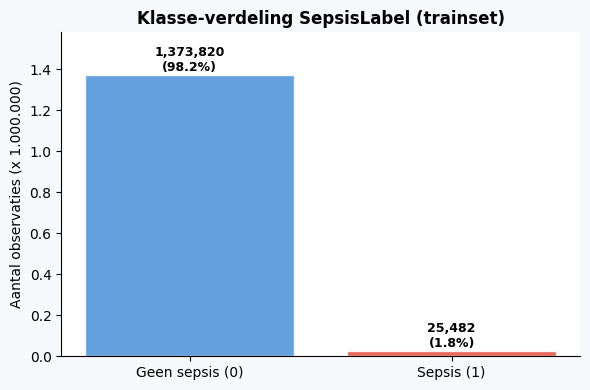

In [14]:
label_counts = df_train['SepsisLabel'].value_counts()
label_pct    = df_train['SepsisLabel'].value_counts(normalize=True).round(4) * 100

print('=== Klasse-verdeling SepsisLabel ===')
print(f'Geen sepsis (0): {label_counts[0]:>10,}  ({label_pct[0]:.2f}%)')
print(f'Sepsis     (1): {label_counts[1]:>10,}  ({label_pct[1]:.2f}%)')
print(f'Verhouding 0:1 = {label_counts[0]//label_counts[1]}:1')

fig, ax = plt.subplots(figsize=(6, 4), facecolor='#f7f9fc')
bars = ax.bar(['Geen sepsis (0)', 'Sepsis (1)'], label_counts.values,
              color=['#4a90d9', '#e74c3c'], edgecolor='white', alpha=0.85)
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, max(label_counts.values) * 1.15)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x / 1_000_000:,.1f}"))
ax.set_title('Klasse-verdeling SepsisLabel (trainset)', fontsize=12, fontweight='bold')
ax.set_ylabel('Aantal observaties (x 1.000.000)')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Er is een sterke **klasse-onbalans**: slechts 1,82% van de observaties heeft een sepsislabel. Een naïef model dat altijd 0 voorspelt behaalt al 98,18% accuracy. Dit maakt accuracy een ongeschikte metric; we focussen op AUROC, recall en precision.

### Missende waarden

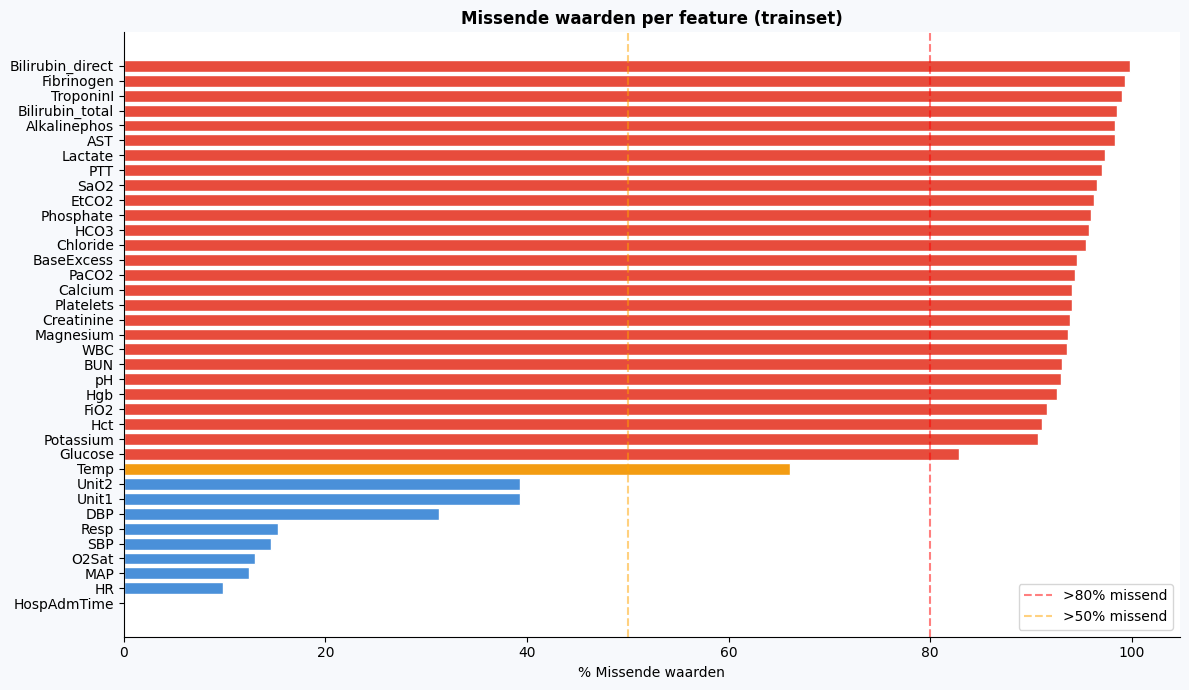

Features met > 80% missende waarden: 27
Features met 50% - 80% missende waarden : 1
Features met < 50% missende waarden (> 0%): 9
Features zonder missende waarden : 7


In [20]:
missing = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Feature', 'Missing (%)']

fig, ax = plt.subplots(figsize=(12, 7), facecolor='#f7f9fc')
colors = ['#e74c3c' if v > 80 else '#f39c12' if v > 50 else '#4a90d9' 
          for v in missing_df['Missing (%)']]
ax.barh(missing_df['Feature'][::-1], missing_df['Missing (%)'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='>80% missend')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='>50% missend')
ax.set_xlabel('% Missende waarden')
ax.set_title('Missende waarden per feature (trainset)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Features met > 80% missende waarden: {(missing > 80).sum()}')
print(f'Features met 50% - 80% missende waarden : {((missing > 50) & (missing <= 80)).sum()}')
print(f'Features met < 50% missende waarden (> 0%): {((missing > 0) & (missing <= 50)).sum()}')
print(f'Features zonder missende waarden : {(missing == 0).sum()}')

De meeste laboratoriumwaarden hebben een hoog percentage missende waarden. Dit is klinisch realistisch: laboratoriumtests worden niet elk uur afgenomen. Vitale parameters (HR, O2Sat, SBP, MAP, Resp) hebben minder missende waarden en worden continu gemonitord.